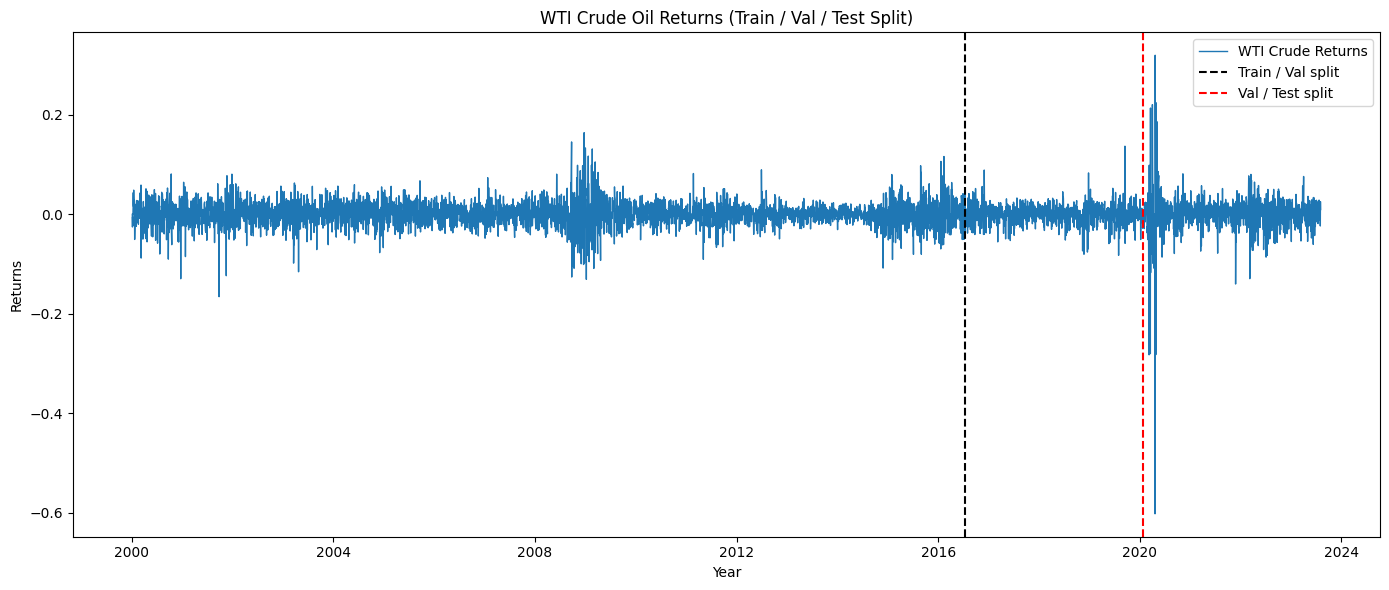

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

train = pd.read_csv("../data/splits/train.csv")
val   = pd.read_csv("../data/splits/val.csv")
test  = pd.read_csv("../data/splits/test.csv")

train["date"] = pd.to_datetime(train["Date"])
val["date"]   = pd.to_datetime(val["Date"])
test["date"]  = pd.to_datetime(test["Date"])

# Ensure numeric
train_y = pd.to_numeric(train["WTI CRUDE"], errors="coerce")
val_y   = pd.to_numeric(val["WTI CRUDE"], errors="coerce")
test_y  = pd.to_numeric(test["WTI CRUDE"], errors="coerce")

# Combine series + dates
full_series = pd.concat([train_y, val_y, test_y]).dropna()
full_dates  = pd.concat([train["date"], val["date"], test["date"]]).iloc[:len(full_series)]

# Set datetime index
full_series.index = full_dates

# Split boundaries (by time, not index)
train_end_date = train["date"].iloc[-1]
val_end_date   = val["date"].iloc[-1]

# Plot
plt.figure(figsize=(14,6))
plt.plot(full_series.index, full_series.values, label="WTI Crude Returns", linewidth=1)

# Vertical split lines
plt.axvline(train_end_date, color="black", linestyle="--", label="Train / Val split")
plt.axvline(val_end_date, color="red", linestyle="--", label="Val / Test split")

# Labels for splits
plt.text(train_end_date, plt.ylim()[1]*0.95, "", color="black")
plt.text(val_end_date, plt.ylim()[1]*0.95, "", color="red")

plt.title("WTI Crude Oil Returns (Train / Val / Test Split)")
plt.xlabel("Year")
plt.ylabel("Returns")
plt.legend()
plt.tight_layout()
plt.show()

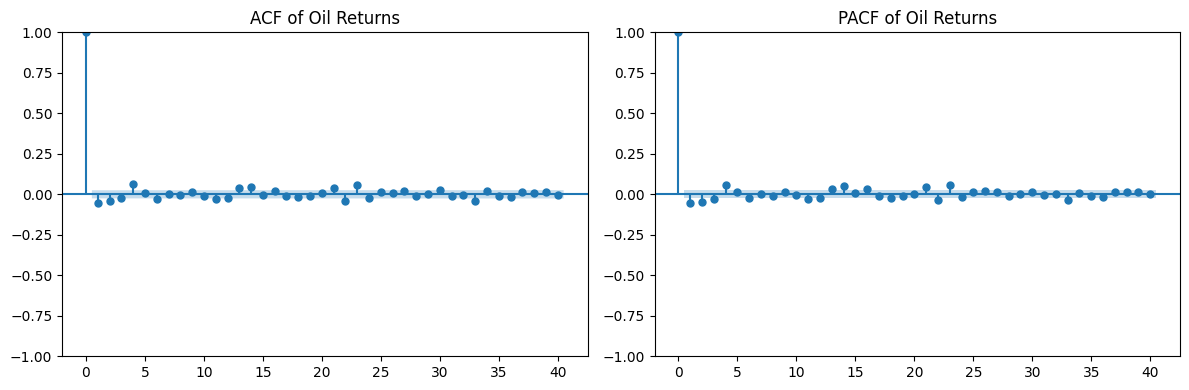

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# assume your returns series is called oil_returns
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(full_series, lags=40, ax=ax[0])
ax[0].set_title("ACF of Oil Returns")

plot_pacf(full_series, lags=40, ax=ax[1])
ax[1].set_title("PACF of Oil Returns")

plt.tight_layout()
plt.show()